**Навигация по уроку**

1. [Библиотеки Python для Data Science](https://colab.research.google.com/drive/1VKRkuVNaSRPy6uNRhWLIlfaTnLPuyWcC)
2. [Отзывы к фильмам (исследуем датасет IMDB)](https://colab.research.google.com/drive/1jL4XbkAMuMNVPXhfsE8Z2Z4h-sGtyAq1)
3. Домашняя работа

Используя базу данных фильмов из практической части урока, проверте следующие гипотезы:

1. Большинство фильмов выпускаются по пятницам
2. Известные актеры снимаются в самых кассовых фильмах
3. Известные актеры снимаются в самыx дорогих фильмах

Построить графики по гипотезам. Сколько актеров из вашего результата вам знакомы?

In [ ]:
from requests import get
response = get("https://storage.yandexcloud.net/academy.ai/the_movies_dataset.zip")

In [ ]:
with open('the_movies_dataset.zip', 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

In [ ]:
# Разархивация датасета в директорию 'the_movies_dataset'
!unzip -qo "the_movies_dataset.zip" -d ./the_movies_dataset

# Папка с распакованным датасетом
FILE_PATH = './the_movies_dataset'

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(f'{FILE_PATH}/movies_metadata.csv')
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
df = df.drop(['imdb_id'], axis=1)
df = df.drop(['adult'], axis=1)
df = df.drop(['belongs_to_collection'], axis=1)
df = df.drop(['homepage'], axis=1)
df = df.drop(['video'], axis=1)
df = df.drop(['poster_path'], axis=1)
df = df.drop(['production_companies'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                45466 non-null  object 
 1   genres                45466 non-null  object 
 2   id                    45466 non-null  object 
 3   original_language     45455 non-null  object 
 4   original_title        45466 non-null  object 
 5   overview              44512 non-null  object 
 6   popularity            45461 non-null  object 
 7   production_countries  45463 non-null  object 
 8   release_date          45379 non-null  object 
 9   revenue               45460 non-null  float64
 10  runtime               45203 non-null  float64
 11  spoken_languages      45460 non-null  object 
 12  status                45379 non-null  object 
 13  tagline               20412 non-null  object 
 14  title                 45460 non-null  object 
 15  vote_average       

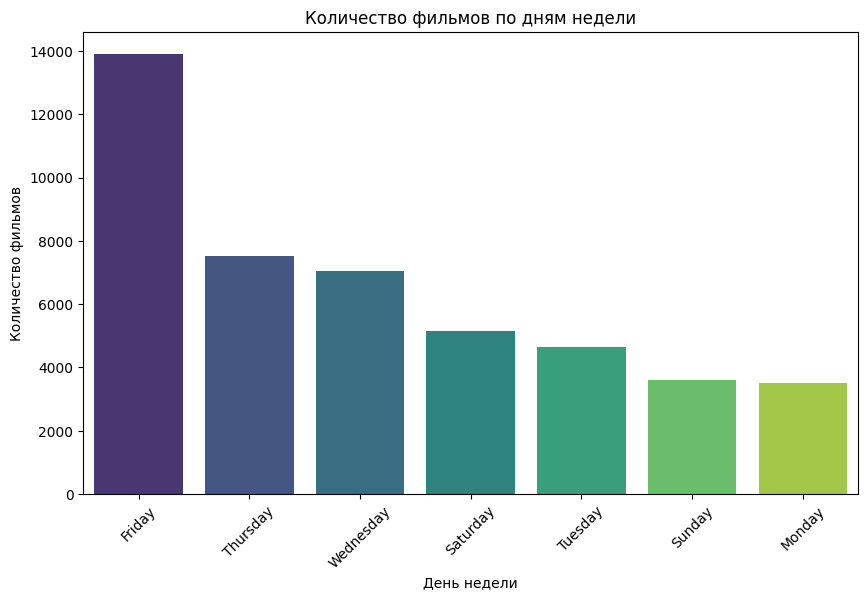

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt  # Библиотека для построения графиков
import seaborn as sns  # Еще одна библиотека для построения графиков, работает как обертка над предыдущей
import pandas as pd  # Библиотека для работы с данными

# Предполагаем, что df уже загружен и содержит столбец 'release_date'
# Преобразуем столбец 'release_date' в формат datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Извлекаем день недели из даты выпуска
df['release_day'] = df['release_date'].dt.day_name()

# Подсчитываем количество фильмов, выпущенных в каждый день недели
release_counts = df['release_day'].value_counts()

# Строим график распределения фильмов по дням недели
plt.figure(figsize=(10, 6))
sns.barplot(x=release_counts.index, y=release_counts.values, palette='viridis')
plt.title('Количество выпускаемых фильмов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество фильмов')
plt.xticks(rotation=45)
plt.show()  # Показать построенный график


In [ ]:
#Известные актеры снимаются в самых кассовых фильмах

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45538 entries, 0 to 45537
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45538 non-null  object 
 1   belongs_to_collection  4500 non-null   object 
 2   budget                 45538 non-null  object 
 3   genres                 45538 non-null  object 
 4   homepage               7792 non-null   object 
 5   id                     45538 non-null  int64  
 6   imdb_id                45521 non-null  object 
 7   original_language      45527 non-null  object 
 8   original_title         45538 non-null  object 
 9   overview               44584 non-null  object 
 10  popularity             45535 non-null  object 
 11  poster_path            45152 non-null  object 
 12  production_companies   45535 non-null  object 
 13  production_countries   45535 non-null  object 
 14  release_date           45451 non-null  object 
 15  re

In [ ]:
from requests import get
response = get("https://storage.yandexcloud.net/academy.ai/the_movies_dataset.zip")

with open('the_movies_dataset.zip', 'wb') as f:
    f.write(response.content)

    # Разархивация датасета в директорию 'the_movies_dataset'
!unzip -qo "the_movies_dataset.zip" -d ./the_movies_dataset

# Папка с распакованным датасетом
FILE_PATH = './the_movies_dataset'

# Для работы с файлами
import os

os.listdir(FILE_PATH)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np

df_movies = pd.read_csv(f'{FILE_PATH}/movies_metadata.csv')
df_movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
df_movies = df_movies.drop(['adult'], axis=1)
df_movies = df_movies.drop(['belongs_to_collection'], axis=1)
df_movies = df_movies.drop(['revenue'], axis=1)
df_movies = df_movies.drop(['genres'], axis=1)
df_movies = df_movies.drop(['homepage'], axis=1)
df_movies = df_movies.drop(['imdb_id'], axis=1)
df_movies = df_movies.drop(['original_language'], axis=1)
df_movies = df_movies.drop(['original_title'], axis=1)
df_movies = df_movies.drop(['overview'], axis=1)
df_movies = df_movies.drop(['poster_path'], axis=1)
df_movies = df_movies.drop(['production_companies'], axis=1)
df_movies = df_movies.drop(['production_countries'], axis=1)
df_movies = df_movies.drop(['release_date'], axis=1)
df_movies = df_movies.drop(['runtime'], axis=1)
df_movies = df_movies.drop(['spoken_languages'], axis=1)
df_movies = df_movies.drop(['status'], axis=1)
df_movies = df_movies.drop(['tagline'], axis=1)
df_movies = df_movies.drop(['video'], axis=1)
df_movies = df_movies.drop(['vote_average'], axis=1)
df_movies = df_movies.drop(['vote_count'], axis=1)

In [ ]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   budget      45466 non-null  object
 1   id          45466 non-null  object
 2   popularity  45461 non-null  object
 3   title       45460 non-null  object
dtypes: object(4)
memory usage: 1.4+ MB


In [ ]:
df_movies[df_movies['budget'] == 0].shape
df_movies['budget'] = df_movies['budget'].replace(0, np.nan)

In [ ]:
df_movies[df_movies['popularity'] == 0].shape
df_movies['popularity'] = df_movies['popularity'].replace(0, np.nan)

In [ ]:
print("Тип столбца popularity:", df_movies.popularity.dtypes)
print("Тип столбца revenue:", df_movies.budget.dtypes)

Тип столбца popularity: object
Тип столбца revenue: object


In [ ]:
df_movies['popularity'] = pd.to_numeric(df_movies['popularity'], errors='coerce') # Пытаемся преобразовать в число, в случае ошибки принуждаем (coerce) к NaN
df_movies['popularity'] = df_movies['popularity'].replace(0, np.nan) # Заменяем 0 на NaN
df_movies[df_movies['popularity'].isnull()].shape # Получаем только записи с numpy.NaN или Python None

(72, 4)

In [ ]:
df_movies[['id', 'title','popularity','budget']].head() # Выводим название фильма и год выпуска

,id,title,popularity,budget
0,862,Toy Story,21.946943,30000000
1,8844,Jumanji,17.015539,65000000
2,15602,Grumpier Old Men,11.712900,0
3,31357,Waiting to Exhale,3.859495,16000000
4,11862,Father of the Bride Part II,8.387519,0


In [ ]:
credits_df = pd.read_csv('./the_movies_dataset/credits.csv')
credits_df.head()

,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844
2,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...",15602
3,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...",31357
4,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...",11862


In [ ]:
credits_df = credits_df.drop(['crew'], axis=1)

In [ ]:
def convert_int(x):
    try:
        return int(x)
    except:
        return np.nan

df_movies['id'] = df_movies['id'].apply(convert_int)  # Преобразуем к int

In [ ]:
df_movies = df_movies.drop(df_movies[df_movies['id'].isnull()].index)

df_movies['id'] = df_movies['id'].astype('int') # установим тип

In [ ]:
df_merge = df_movies.merge(credits_df, on='id')
df_merge.shape

(45538, 5)

In [ ]:
import ast
df_merge['cast'] = df_merge['cast'].apply(ast.literal_eval) # Строку в словарь '{"a": 1}' -> {'a': 1}

In [ ]:
def get_name(x):
    for i in x:
        return i['name']
    return np.nan

df_merge['name'] = df_merge['cast'].apply(get_name)

[{\'credit_id\': \'52fe4284c3a36847f8024f49\', \'department\': \'Directing\', \'gender\': 2, \'id\': 7879, \'job\': \'Director\', \'name\': \'John Lasseter\', \'profile_path\': \'/7EdqiNbr4FRjIhKHyPPdFfEEEFG.jpg\'},

In [ ]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45538 entries, 0 to 45537
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   budget      45538 non-null  object 
 1   id          45538 non-null  int64  
 2   popularity  45469 non-null  float64
 3   title       45535 non-null  object 
 4   cast        45538 non-null  object 
 5   name        43118 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 2.1+ MB


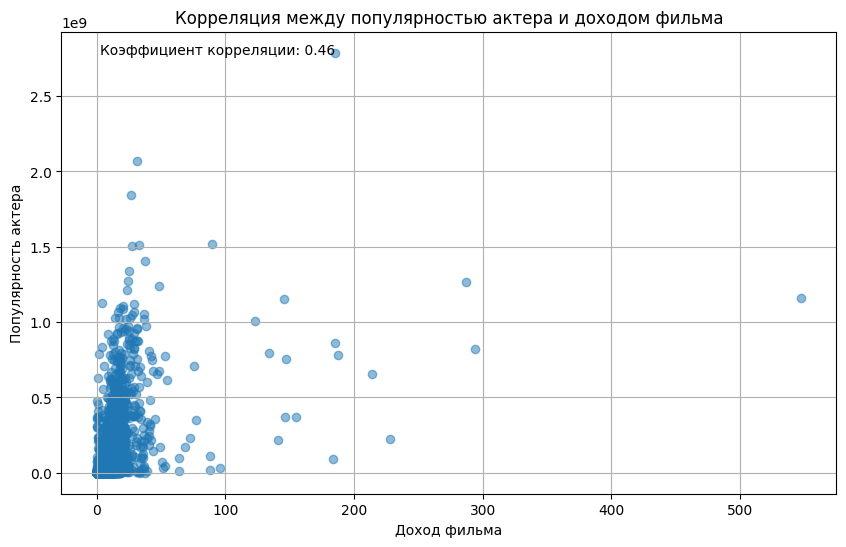

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Создание точечного графика
plt.figure(figsize=(10, 6))  # Увеличение размера графика для лучшей читаемости
plt.scatter(df_merge['popularity'], df_merge['revenue'], alpha=0.5) # alpha добавляет прозрачность, чтобы избежать перекрытия точек

plt.xlabel('Доход фильма')
plt.ylabel('Популярность актера')
plt.title('Корреляция между популярностью актера и доходом фильма')
plt.grid(True)  # Добавление сетки для лучшей читаемости

# Вычисление коэффициента корреляции Пирсона (для количественной оценки корреляции)
correlation = df_merge['popularity'].corr(df_merge['revenue'])
plt.text(0.05, 0.95, f'Коэффициент корреляции: {correlation:.2f}', transform=plt.gca().transAxes)

plt.show()

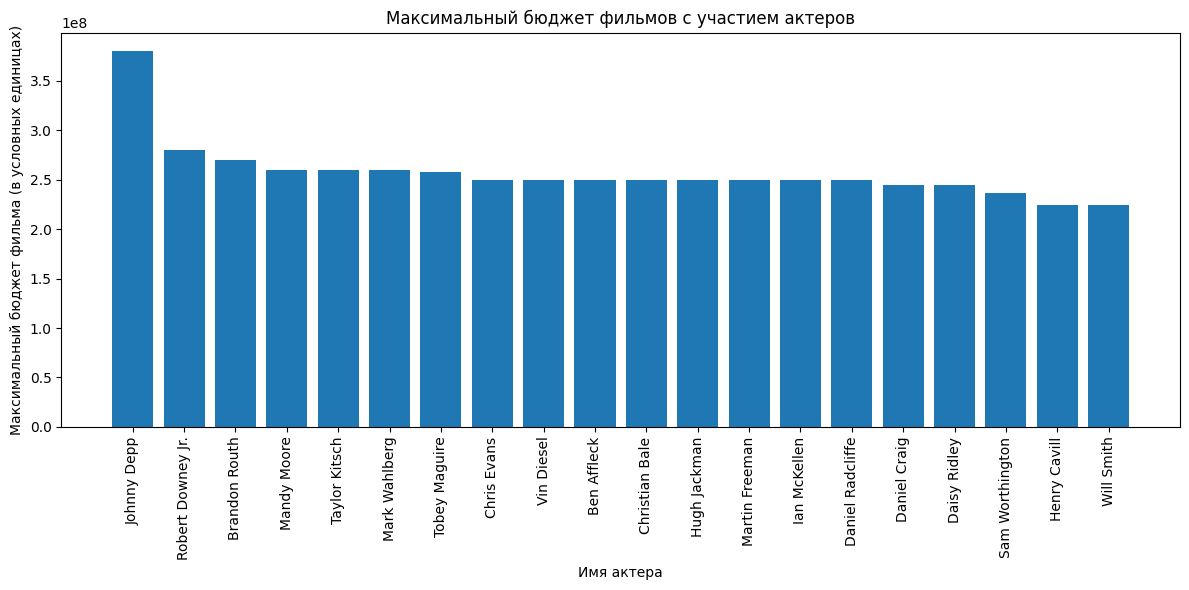

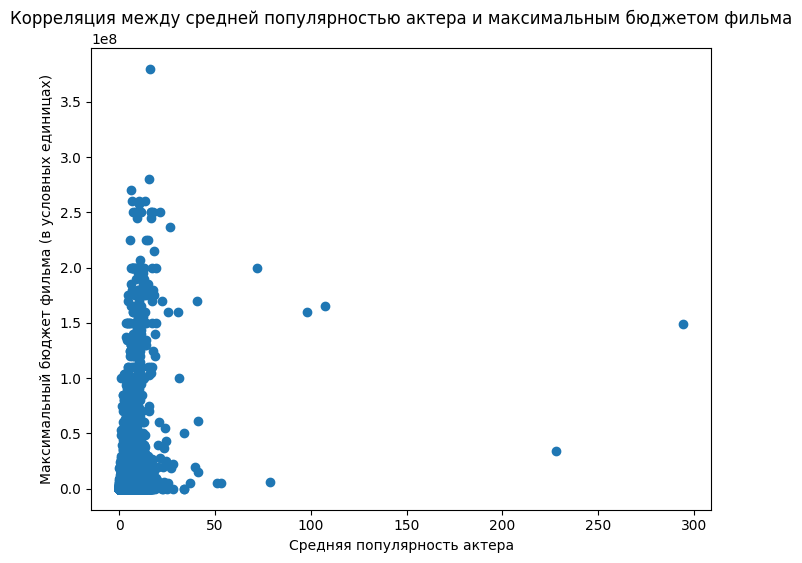

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Предполагаем, что данные находятся в DataFrame под названием `df`

# Очистка и преобразование столбца 'budget' (как и раньше)
df_merge['budget'] = df_merge['budget'].astype(str).str.replace(r'[$,]', '', regex=True)
df_merge['budget'] = pd.to_numeric(df_merge['budget'], errors='coerce')
df_merge.dropna(subset=['budget'], inplace=True)

# Группировка по актерам и нахождение максимального бюджета для каждого
actor_max_budget = df_merge.groupby('name')['budget'].max()

# Сортировка по убыванию бюджета
actor_max_budget = actor_max_budget.sort_values(ascending=False)


# Построение столбчатой диаграммы с 20 самыми высокими бюджетами
plt.figure(figsize=(12, 6))
plt.bar(actor_max_budget.index[:20], actor_max_budget.values[:20])
plt.xticks(rotation=90)
plt.xlabel("Имя актера")
plt.ylabel("Максимальный бюджет фильма (в условных единицах)")
plt.title("Максимальный бюджет фильмов с участием актеров")
plt.tight_layout()
plt.show()


# График корреляции:  Теперь используем максимальный бюджет, а не средний.
plt.figure(figsize=(8, 6))
#Для корректного сравнения  нужно использовать среднее значение популярности актеров.  Максимальный бюджет исказит данные, если у актера одна роль в дорогом фильме и много ролей в дешевых
plt.scatter(df_merge.groupby('name')['popularity'].mean(), df_merge.groupby('name')['budget'].max()) #изменил на max
plt.xlabel("Средняя популярность актера")
plt.ylabel("Максимальный бюджет фильма (в условных единицах)")
plt.title("Корреляция между средней популярностью актера и максимальным бюджетом фильма")
plt.show()



#Сколько актеров из вашего результата вам знакомы?
Знакомы все.)